# 06 · Forecasting

**Goal:** project EV market-share trends forward using Prophet, as a way to visualize where
the transition might be headed — framed honestly as a trend extrapolation, not a prediction
you'd bet money on.

**Honest framing:** with 5–15 yearly points per country, any forecasting model will produce
wide confidence intervals. This is expected and worth showing as-is in a portfolio — it
demonstrates you understand the limits of your own model, which is itself a data-analysis
skill. If monthly data becomes available later (e.g. from central banks), forecasts here
would improve meaningfully.

In [2]:
import sys
sys.path.append('../src')
from utils import DATA_PROCESSED, OWID_COUNTRIES
import pandas as pd
import matplotlib.pyplot as plt

df_share = pd.read_csv(DATA_PROCESSED / "iea_ev_sales_share_latam.csv")
value_col = [col for col in df_share.columns if col not in ('Entity','Code','Year')][0]

## 1. Forecast EV market share per country

15:00:12 | INFO | Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
15:00:12 | INFO | Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
15:00:12 | INFO | n_changepoints greater than number of observations. Using 11.
15:00:12 | INFO | Chain [1] start processing
15:00:12 | INFO | Chain [1] done processing


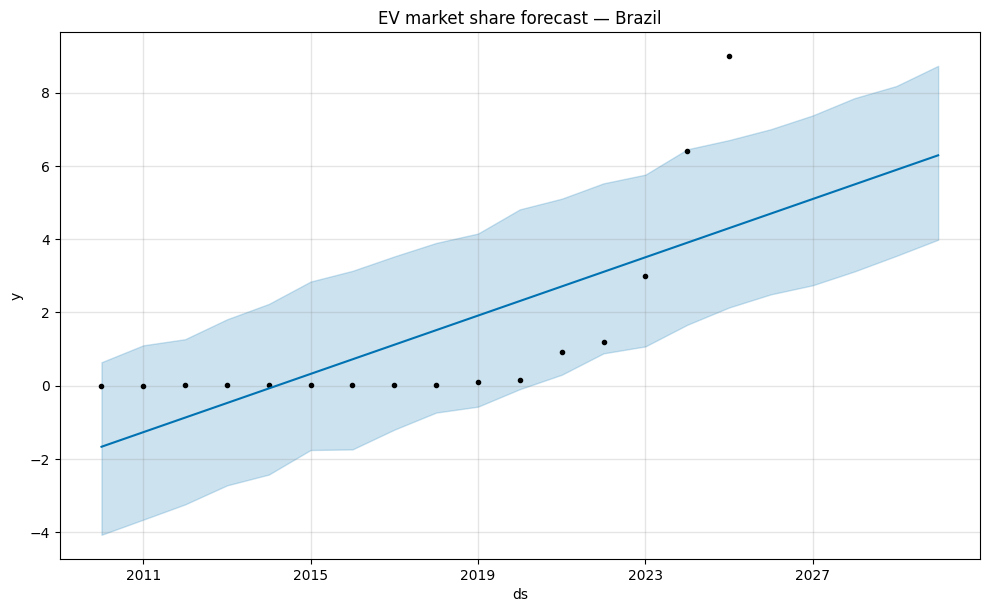

In [3]:
from prophet import Prophet

def forecast_country(country: str, periods_ahead: int = 5):
    subset = df_share[df_share['Entity'] == country][['Year', value_col]].copy()
    subset.columns = ['ds', 'y']
    subset['ds'] = pd.to_datetime(subset['ds'], format='%Y')

    model = Prophet(yearly_seasonality=False)
    model.fit(subset)

    future = model.make_future_dataframe(periods=periods_ahead, freq='YE')
    forecast = model.predict(future)
    return model, forecast

# Example: Brazil
model_br, forecast_br = forecast_country('Brazil')
fig = model_br.plot(forecast_br)
plt.title("EV market share forecast — Brazil")
plt.show()

In [4]:
# Repeat for all IEA-covered countries and consolidate into one comparison table
iea_covered = [c for c in OWID_COUNTRIES if c in df_share['Entity'].unique()]

forecast_summary = []
for country in iea_covered:
    _, fc = forecast_country(country)
    last_row = fc.iloc[-1]
    forecast_summary.append({
        'Country': country,
        'projected_year': last_row['ds'].year,
        'projected_share_%': round(last_row['yhat'], 2),
        'lower_bound_%': round(last_row['yhat_lower'], 2),
        'upper_bound_%': round(last_row['yhat_upper'], 2),
    })

pd.DataFrame(forecast_summary)

15:00:16 | INFO | Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
15:00:16 | INFO | Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
15:00:17 | INFO | n_changepoints greater than number of observations. Using 11.
15:00:17 | INFO | Chain [1] start processing
15:00:17 | INFO | Chain [1] done processing
15:00:17 | INFO | Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
15:00:17 | INFO | Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
15:00:17 | INFO | n_changepoints greater than number of observations. Using 11.
15:00:17 | INFO | Chain [1] start processing
15:00:17 | INFO | Chain [1] done processing
15:00:17 | INFO | Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
15:00:17 | INFO | Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
15:00:17 | INFO | n_change

,Country,projected_year,projected_share_%,lower_bound_%,upper_bound_%
0,Brazil,2029,6.29,3.99,8.64
1,Mexico,2029,4.17,2.51,5.67
2,Chile,2029,2.62,1.61,3.58
3,Colombia,2029,8.12,5.59,10.54


## 2. Suggested next steps

- Bring in the OWID lithium-ion battery price dataset to test price vs. adoption correlation
  over time (extends the correlation work from notebook 05).
- Once BCRP/ComexStat monthly series are confirmed and extended, re-run forecasts with
  monthly granularity — this alone would substantially tighten the confidence intervals.
- Export the final tables (EDA + statistical summary + forecast) to `data/processed/` in wide
  format (country × year) — this is the shape Power BI imports most cleanly.
- For Power BI: build one fact table per theme (adoption, imports-by-origin, forecast) rather
  than one giant merged table — keeps relationships simple in the BI model.

## Findings

The 2029 projection keeps Colombia in the lead (8.1% EV share, range 5.8-10.5%) and Brazil
second (6.3%, range 3.9-8.6%), consistent with their being the two fastest, most statistically
reliable trends identified in notebook 05. Mexico and Chile trail behind.

**Limitation to keep in mind:** these are trend extrapolations from 15-16 yearly points per
country — the confidence intervals are wide (roughly +/-2 to 3 percentage points) precisely
because the sample is small. Read this chart as "the direction and rough pace look like this
if nothing structural changes," not as a firm target. It would tighten meaningfully with
monthly data, which is why notebook 03's central-bank series are worth extending over time.